# NB2 : Char, Hybrid et Classifieurs variés avec Tuning

## Contexte

Ce notebook fait suite à NB1 qui a établi nos baselines avec CountVectorizer
et TF-IDF Word. Le meilleur pipeline de NB1 était **P03_TFIDF_UniBi_LogReg**
avec un F1 classe 1 de **0.710** après tuning.

L'objectif ici est d'explorer de nouvelles approches de vectorisation
(Char et Hybrid) et de nouveaux classifieurs pour tenter de dépasser
ce score de référence.

---

## Nouvelles approches testées

### 1. Vectorisation Char (analyzer='char_wb')
Au lieu de découper le texte en mots, on découpe en **séquences de
caractères** (n-grams de caractères). 
**Pourquoi c'est utile pour les tweets ?**
* Capture les **hashtags** (#earthquake → séquences de caractères)
* Gère les **abréviations** ("omg" → trigramme "omg" entier)
* Robuste aux **fautes de frappe** ("earthquak" partage beaucoup de
  trigrammes avec "earthquake")
* Capture les **mots collés** sans espaces

### 2. Vectorisation Hybrid (Word + Char)
Combine les deux approches via `FeatureUnion` :
* **TF-IDF Word** : capture le sens des mots et expressions
* **TF-IDF Char** : capture les spécificités du langage Twitter

Le vecteur final est la **concaténation** des deux représentations —
on obtient le meilleur des deux mondes.
"fire broke out"

↓ Word TF-IDF              ↓ Char TF-IDF

["fire":0.8, "broke":0.6,...] + [" fi":0.3, "fir":0.4,...]

↓

Vecteur final = [word_features | char_features]
### 3. Nouveaux classifieurs
* **ComplementNB** : variante de Naive Bayes conçue spécifiquement pour
  les datasets déséquilibrés et estime la probabilité qu'un document
  **n'appartienne pas** à chaque classe plutôt que la probabilité
  d'appartenance directe
* **BernoulliNB** : Naive Bayes pour données binaires (présence/absence
  d'un mot, pas son compte)
* **SGD Hinge** : équivalent à un LinearSVC entraîné par descente de
  gradient stochastique
* **SGD Modified Huber** : variante probabiliste de SGD, bon compromis
  entre robustesse et capacité à produire des probabilités

---

## Pipelines testés (P06 à P10)

| Pipeline | Vectorisation | Classifieur | Particularité |
|---|---|---|---|
| P06 | TF-IDF Char | ComplementNB | Char + NB déséquilibre |
| P07 | TF-IDF Char | LinearSVC | Char + meilleur classique |
| P08 | TF-IDF Word | LogReg Balanced | Déséquilibre explicite |
| P09 | Hybrid Word+Char | LogReg | Meilleur des deux mondes |
| P10 | Hybrid Word+Char | LinearSVC | Meilleur combo attendu |

---

## Validation

Comme dans NB1, on utilise **GridSearchCV avec Stratified K-Fold (5 folds)**
pour le tuning des hyperparamètres :

* Chaque combinaison d'hyperparamètres est évaluée 5 fois sur des
  découpages différents du train set
* Le score retenu est la **moyenne des 5 F1 classe 1**
* La combinaison avec le meilleur score moyen est sélectionnée
* Le meilleur modèle est ré-entraîné automatiquement sur tout X_train

---

## Objectif

Dépasser le score de référence de NB1 :
* **F1 classe 1 > 0.710** (P03_TFIDF_UniBi_LogReg)
* **Recall classe 1 > 0.771**

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd                          # manipulation des données tabulaires
import numpy as np                           # calcul numérique
import matplotlib.pyplot as plt              # visualisation
import seaborn as sns                        # visualisation statistique
import json                                  # sérialisation des paramètres
import warnings
from collections import OrderedDict          # dictionnaire ordonné pour les pipelines

from sklearn.pipeline import Pipeline, FeatureUnion    # enchaînement et combinaison de transformeurs
from sklearn.feature_extraction.text import (
    TfidfVectorizer,                                   # pondération TF-IDF des mots/caractères
    CountVectorizer                                    # comptage brut des occurrences
)
from sklearn.naive_bayes import (
    MultinomialNB,    # Naive Bayes pour données de comptage
    BernoulliNB,      # Naive Bayes pour données binaires (présence/absence)
    ComplementNB      # Naive Bayes adapté aux datasets déséquilibrés
)
from sklearn.linear_model import LogisticRegression, SGDClassifier  # modèles linéaires
from sklearn.svm import LinearSVC                                    # SVM linéaire

from sklearn.metrics import (
    f1_score,                  # F1-score : équilibre précision/rappel
    accuracy_score,            # proportion de prédictions correctes
    precision_score,           # parmi les prédits positifs, combien le sont vraiment
    recall_score,              # parmi les vrais positifs, combien sont détectés
    balanced_accuracy_score,   # moyenne du recall par classe
    classification_report,     # rapport complet par classe
    confusion_matrix           # matrice de confusion
)

from sklearn.model_selection import (
    GridSearchCV,       # recherche des meilleurs hyperparamètres par validation croisée
    StratifiedKFold     # K-Fold stratifié : conserve les proportions des classes dans chaque fold
)

warnings.filterwarnings('ignore')
print('✅ Imports effectués avec succès')

✅ Imports effectués avec succès


## Chargement des données

On charge les mêmes datasets nettoyés que dans NB1. Le score de référence
à battre est **F1 classe 1 = 0.710** obtenu par P03_TFIDF_UniBi_LogReg.

In [2]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
TEXT_COL      = 'text_lemma'   # colonne de texte utilisée pour la vectorisation
LABEL_COL     = 'target'       # variable cible (0 = non-disaster, 1 = disaster)
RANDOM_STATE  = 42             # graine aléatoire pour la reproductibilité
REFERENCE_F1  = 0.710          # score de référence à battre (meilleur NB1)

FEATURES_NUM = [
    'word_count', 'mean_word_length', 'lexical_diversity',
    'stop_word_count', 'url_count', 'punctuation_count',
    'hashtag_count', 'keyword_disaster_rate'
]

# ── CHARGEMENT DES DONNÉES ────────────────────────────────────────────────────
train = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/train_cleaned.csv')
test  = pd.read_csv('/kaggle/input/notebooks/aissatousamb/eda-tweets/test_cleaned.csv')

# Remplacement des NaN dans text_lemma par une chaîne vide
train['text_lemma'] = train['text_lemma'].fillna('')
test['text_lemma']  = test['text_lemma'].fillna('')

# Définition de X et y
X_train = train[TEXT_COL]
X_test  = test[TEXT_COL]
y_train = train[LABEL_COL]
y_test  = test[LABEL_COL]

print(f"Taille train : {len(X_train)}")
print(f"Taille test  : {len(X_test)}")
print(f"\nDistribution des classes - train :")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f"\nDistribution des classes - test :")
print(y_test.value_counts(normalize=True).sort_index().round(3))
print(f"\n🎯 Score de référence à battre (NB1) : F1 classe 1 = {REFERENCE_F1}")

Taille train : 8979
Taille test  : 2245

Distribution des classes - train :
target
0    0.815
1    0.185
Name: proportion, dtype: float64

Distribution des classes - test :
target
0    0.815
1    0.185
Name: proportion, dtype: float64

🎯 Score de référence à battre (NB1) : F1 classe 1 = 0.71


## Définition des pipelines

On définit ici 5 nouveaux pipelines (P06 à P10) qui explorent :
- La vectorisation au niveau des **caractères** (`char_wb`)
- La vectorisation **hybride** (word + char combinés)
- De nouveaux classifieurs (ComplementNB, BernoulliNB, SGD variantes)

**Paramètres des vectoriseurs Char :**
* `analyzer='char_wb'` : découpe en n-grams de caractères dans les
  frontières de mots (wb = word boundary) — plus propre que `char` car
  un n-gram ne peut pas être à cheval sur deux mots
* `ngram_range=(2,4)` : bigrammes à quadrigrammes de caractères —
  captures des séquences significatives sans être trop spécifiques

**FeatureUnion pour le Hybrid :**
`FeatureUnion` combine deux vectoriseurs en parallèle et concatène
leurs sorties en un seul vecteur. Contrairement à `Pipeline` qui
enchaîne les étapes séquentiellement, `FeatureUnion` les exécute
en parallèle sur le même input.

In [3]:
# ── DÉFINITION DES PIPELINES P06 À P10 ───────────────────────────────────────
pipelines = OrderedDict({

    # P06 : TF-IDF Char + ComplementNB
    # Vectorisation au niveau des caractères + NB adapté au déséquilibre
    # ComplementNB est conçu pour les datasets déséquilibrés comme le nôtre
    "P06_TFIDF_Char_ComplementNB": Pipeline([
        ("vect", TfidfVectorizer(
            analyzer='char_wb',      # n-grams de caractères dans les frontières de mots
            ngram_range=(2,4),       # bigrammes à quadrigrammes de caractères
            min_df=2,                # ignore les n-grams trop rares
            max_df=0.95              # ignore les n-grams trop fréquents
        )),
        ("clf", ComplementNB())
    ]),

    # P07 : TF-IDF Char + LinearSVC
    # Vectorisation caractères + SVM linéaire
    # LinearSVC est souvent le meilleur classifieur classique en NLP
    "P07_TFIDF_Char_LinearSVC": Pipeline([
        ("vect", TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(2,4),
            min_df=2,
            max_df=0.95
        )),
        ("clf", LinearSVC(C=1.0))
    ]),

    # P08 : TF-IDF Word + LogReg Balanced
    # Même vectorisation que NB1 mais avec class_weight='balanced' par défaut
    # Compare directement avec P03 de NB1 (meilleur résultat précédent)
    "P08_TFIDF_Word_LogReg_Balanced": Pipeline([
        ("vect", TfidfVectorizer(
            analyzer='word',
            ngram_range=(1,2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True        # log(TF) au lieu de TF brut
        )),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight='balanced'  # compense le déséquilibre 81/19
        ))
    ]),

    # P09 : Hybrid (Word + Char) + LogReg
    # Combine TF-IDF Word et TF-IDF Char via FeatureUnion
    # Le vecteur final = [features_word | features_char]
    "P09_Hybrid_LogReg": Pipeline([
        ("vect", FeatureUnion([
            ("word", TfidfVectorizer(
                analyzer='word',
                ngram_range=(1,2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )),
            ("char", TfidfVectorizer(
                analyzer='char_wb',
                ngram_range=(2,4),
                min_df=2,
                max_df=0.95
            ))
        ])),
        ("clf", LogisticRegression(max_iter=2000))
    ]),

    # P10 : Hybrid (Word + Char) + LinearSVC
    # Meilleure vectorisation (hybrid) + meilleur classifieur classique (LinearSVC)
    # Pipeline le plus ambitieux de ce notebook — attendu comme meilleur résultat
    "P10_Hybrid_LinearSVC": Pipeline([
        ("vect", FeatureUnion([
            ("word", TfidfVectorizer(
                analyzer='word',
                ngram_range=(1,2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )),
            ("char", TfidfVectorizer(
                analyzer='char_wb',
                ngram_range=(2,4),
                min_df=2,
                max_df=0.95
            ))
        ])),
        ("clf", LinearSVC(C=1.0))
    ]),
})

print(f"✅ {len(pipelines)} pipelines définis (P06 à P10)")
for name in pipelines:
    print(f"   → {name}")

✅ 5 pipelines définis (P06 à P10)
   → P06_TFIDF_Char_ComplementNB
   → P07_TFIDF_Char_LinearSVC
   → P08_TFIDF_Word_LogReg_Balanced
   → P09_Hybrid_LogReg
   → P10_Hybrid_LinearSVC


## Phase 1 — Baselines sans optimisation

Comme dans NB1, on commence par entraîner chaque pipeline avec ses
paramètres par défaut pour avoir une première idée des performances
brutes. On compare également avec le score de référence de NB1
(F1 classe 1 = 0.710).

In [4]:
# ── PHASE 1 : BASELINES ───────────────────────────────────────────────────────
print("=" * 70)
print("PHASE 1 — BASELINES SANS OPTIMISATION")
print(f"Score de référence NB1 : F1 classe 1 = {REFERENCE_F1}")
print("=" * 70)

baseline_results = []

for name, pipeline in pipelines.items():
    print(f"\n→ Entraînement : {name}")

    # Entraînement du pipeline complet (vectoriseur + classifieur)
    pipeline.fit(X_train, y_train)

    # Prédictions sur train et test
    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)

    # Calcul des métriques
    test_f1 = f1_score(y_test, y_pred_test)
    baseline_results.append({
        'pipeline'                : name,
        'train_accuracy'          : accuracy_score(y_train, y_pred_train),
        'train_f1_class_1'        : f1_score(y_train, y_pred_train),
        'train_recall_class_1'    : recall_score(y_train, y_pred_train),
        'train_precision_class_1' : precision_score(y_train, y_pred_train),
        'test_accuracy'           : accuracy_score(y_test, y_pred_test),
        'test_f1_class_1'         : test_f1,
        'test_recall_class_1'     : recall_score(y_test, y_pred_test),
        'test_precision_class_1'  : precision_score(y_test, y_pred_test),
        'test_f1_macro'           : f1_score(y_test, y_pred_test, average='macro'),
        'test_balanced_accuracy'  : balanced_accuracy_score(y_test, y_pred_test),
    })

    # Indicateur visuel : dépasse-t-on le score de référence ?
    flag = "🟢 DÉPASSE NB1 !" if test_f1 > REFERENCE_F1 else "🔴 En dessous de NB1"
    print(f"   ✅ F1 classe 1 : {test_f1:.3f} | "
          f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
          f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f} | {flag}")

# Tableau comparatif baseline
baseline_df = pd.DataFrame(baseline_results).round(3)
baseline_df = baseline_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Baseline NB2 ===")
display(baseline_df)

PHASE 1 — BASELINES SANS OPTIMISATION
Score de référence NB1 : F1 classe 1 = 0.71

→ Entraînement : P06_TFIDF_Char_ComplementNB
   ✅ F1 classe 1 : 0.414 | Recall : 0.284 | Accuracy : 0.851 | 🔴 En dessous de NB1

→ Entraînement : P07_TFIDF_Char_LinearSVC
   ✅ F1 classe 1 : 0.655 | Recall : 0.610 | Accuracy : 0.882 | 🔴 En dessous de NB1

→ Entraînement : P08_TFIDF_Word_LogReg_Balanced
   ✅ F1 classe 1 : 0.695 | Recall : 0.798 | Accuracy : 0.870 | 🔴 En dessous de NB1

→ Entraînement : P09_Hybrid_LogReg
   ✅ F1 classe 1 : 0.621 | Recall : 0.494 | Accuracy : 0.889 | 🔴 En dessous de NB1

→ Entraînement : P10_Hybrid_LinearSVC
   ✅ F1 classe 1 : 0.684 | Recall : 0.639 | Accuracy : 0.891 | 🔴 En dessous de NB1

=== Tableau comparatif — Phase Baseline NB2 ===


,pipeline,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
2,P08_TFIDF_Word_LogReg_Balanced,0.944,0.862,0.954,0.786,0.870,0.695,0.798,0.615,0.806,0.842
4,P10_Hybrid_LinearSVC,0.998,0.995,0.994,0.996,0.891,0.684,0.639,0.736,0.809,0.793
1,P07_TFIDF_Char_LinearSVC,0.972,0.919,0.873,0.971,0.882,0.655,0.610,0.709,0.792,0.776
3,P09_Hybrid_LogReg,0.933,0.784,0.659,0.967,0.889,0.621,0.494,0.837,0.778,0.736
0,P06_TFIDF_Char_ComplementNB,0.864,0.481,0.341,0.814,0.851,0.414,0.284,0.761,0.664,0.632


## Visualisation des résultats baseline

On compare les 5 nouveaux pipelines entre eux et avec le score de
référence de NB1 (ligne pointillée rouge).

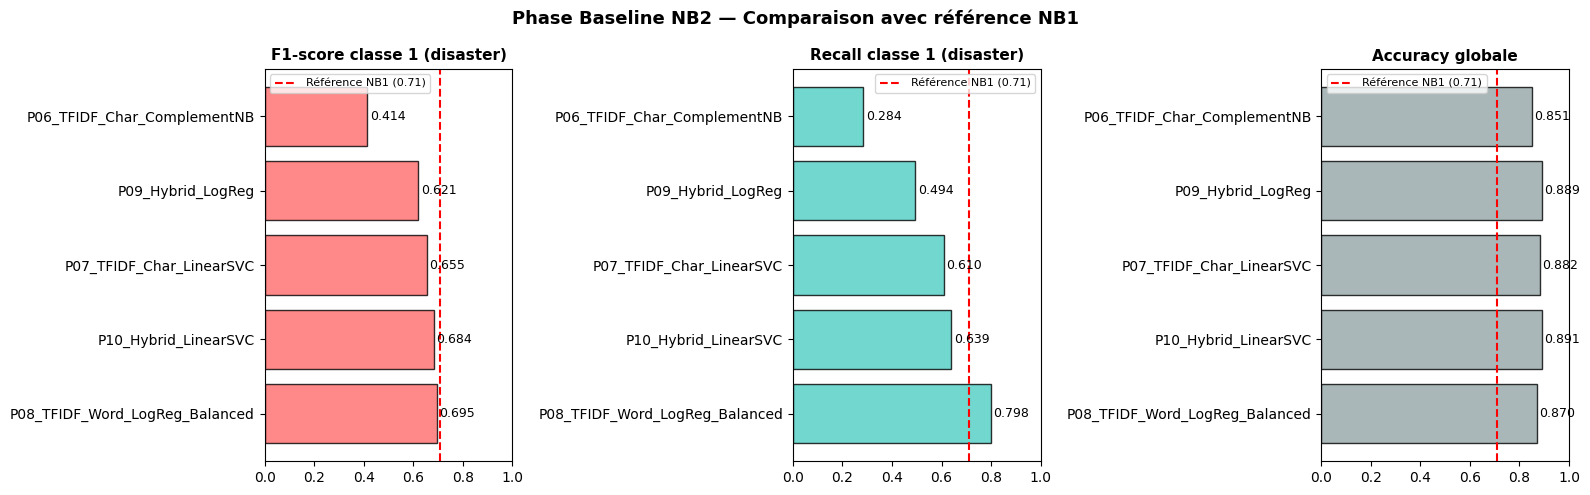

In [5]:
# ── VISUALISATION BASELINE ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['test_f1_class_1', 'test_recall_class_1', 'test_accuracy']
titles  = ['F1-score classe 1 (disaster)', 'Recall classe 1 (disaster)', 'Accuracy globale']
colors  = ['#FF6B6B', '#4ECDC4', '#95A5A6']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    bars = ax.barh(baseline_df['pipeline'], baseline_df[metric],
                   color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1)
    # Ligne de référence NB1
    ax.axvline(REFERENCE_F1, color='red', linestyle='--',
               linewidth=1.5, label=f'Référence NB1 ({REFERENCE_F1})')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, baseline_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Phase Baseline NB2 — Comparaison avec référence NB1',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 2 — Tuning avec GridSearchCV et K-Fold Stratifié

On applique le même protocole de tuning que dans NB1 :

1. **GridSearchCV** teste toutes les combinaisons d'hyperparamètres
   définies dans la grille
2. Pour chaque combinaison, un **Stratified K-Fold à 5 folds** évalue
   les performances — chaque fold conserve les proportions 81/19
3. La métrique de sélection est le **F1-score de la classe 1** (disaster)
4. Le meilleur modèle est ré-entraîné automatiquement sur tout X_train

**Particularité pour les pipelines Hybrid :**
Avec `FeatureUnion`, le préfixe des paramètres devient :
`vect__word__` ou `vect__char__` pour cibler chaque vectoriseur
séparément, ou `clf__` pour le classifieur.

In [6]:
# ── GRILLES D'HYPERPARAMÈTRES ─────────────────────────────────────────────────
param_grids = {
    # ComplementNB : alpha = paramètre de lissage
    # norm=True/False : normalisation des poids (spécifique à ComplementNB)
    "P06_TFIDF_Char_ComplementNB": {
        "clf__alpha": [0.1, 0.5, 1.0, 2.0],
        "clf__norm" : [True, False]
    },

    # LinearSVC sur char : C = force de régularisation
    # class_weight : balanced pour compenser le déséquilibre
    "P07_TFIDF_Char_LinearSVC": {
        "clf__C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "clf__class_weight": [None, "balanced"]
    },

    # LogReg balanced : C = régularisation
    # max_iter déjà fixé à 2000 dans le pipeline
    "P08_TFIDF_Word_LogReg_Balanced": {
        "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0]
    },

    # Hybrid LogReg : C + class_weight
    "P09_Hybrid_LogReg": {
        "clf__C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "clf__class_weight": [None, "balanced"]
    },

    # Hybrid LinearSVC : C + class_weight
    "P10_Hybrid_LinearSVC": {
        "clf__C"           : [0.25, 0.5, 1.0, 2.0, 4.0],
        "clf__class_weight": [None, "balanced"]
    },
}

print("✅ Grilles d'hyperparamètres définies")
for name, grid in param_grids.items():
    n_combinations = 1
    for values in grid.values():
        n_combinations *= len(values)
    print(f"   → {name} : {n_combinations} combinaisons × 5 folds = "
          f"{n_combinations * 5} entraînements")

✅ Grilles d'hyperparamètres définies
   → P06_TFIDF_Char_ComplementNB : 8 combinaisons × 5 folds = 40 entraînements
   → P07_TFIDF_Char_LinearSVC : 10 combinaisons × 5 folds = 50 entraînements
   → P08_TFIDF_Word_LogReg_Balanced : 5 combinaisons × 5 folds = 25 entraînements
   → P09_Hybrid_LogReg : 10 combinaisons × 5 folds = 50 entraînements
   → P10_Hybrid_LinearSVC : 10 combinaisons × 5 folds = 50 entraînements


In [7]:
# ── PHASE 2 : GRIDSEARCHCV + K-FOLD ──────────────────────────────────────────
print("=" * 70)
print("PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)")
print(f"Score de référence NB1 : F1 classe 1 = {REFERENCE_F1}")
print("=" * 70)

# Validation croisée stratifiée en 5 folds
# Stratifié = chaque fold conserve les proportions 81/19 disaster/non-disaster
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_results = []

for name, pipeline in pipelines.items():
    print(f"\n{'='*70}")
    print(f"Tuning → {name}")

    param_grid = param_grids.get(name)
    if param_grid is None:
        print("Aucune grille définie — pipeline ignoré")
        continue

    # GridSearchCV :
    # - teste toutes les combinaisons de param_grid
    # - pour chaque combinaison, fait un 5-Fold stratifié
    # - garde la combinaison qui maximise le F1 classe 1
    # - refit=True (défaut) : ré-entraîne le meilleur modèle sur tout X_train
    grid_search = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grid,
        cv         = cv,
        scoring    = 'f1',
        n_jobs     = -1,
        verbose    = 1
    )

    grid_search.fit(X_train, y_train)

    print(f"   Meilleurs paramètres : {grid_search.best_params_}")
    print(f"   Meilleur F1 (CV)     : {grid_search.best_score_:.3f}")

    # Prédictions avec le meilleur modèle
    y_pred_train = grid_search.predict(X_train)
    y_pred_test  = grid_search.predict(X_test)

    test_f1 = f1_score(y_test, y_pred_test)
    flag = "🟢 DÉPASSE NB1 !" if test_f1 > REFERENCE_F1 else "🔴 En dessous de NB1"

    tuned_results.append({
        'pipeline'                : name,
        'best_params'             : json.dumps(grid_search.best_params_),
        'best_cv_f1_class_1'      : grid_search.best_score_,
        'train_accuracy'          : accuracy_score(y_train, y_pred_train),
        'train_f1_class_1'        : f1_score(y_train, y_pred_train),
        'train_recall_class_1'    : recall_score(y_train, y_pred_train),
        'train_precision_class_1' : precision_score(y_train, y_pred_train),
        'test_accuracy'           : accuracy_score(y_test, y_pred_test),
        'test_f1_class_1'         : test_f1,
        'test_recall_class_1'     : recall_score(y_test, y_pred_test),
        'test_precision_class_1'  : precision_score(y_test, y_pred_test),
        'test_f1_macro'           : f1_score(y_test, y_pred_test, average='macro'),
        'test_balanced_accuracy'  : balanced_accuracy_score(y_test, y_pred_test),
    })

    print(f"   ✅ Test F1 classe 1 : {test_f1:.3f} | "
          f"Recall : {recall_score(y_test, y_pred_test):.3f} | "
          f"Accuracy : {accuracy_score(y_test, y_pred_test):.3f} | {flag}")

# Tableau comparatif tuning
tuned_df = pd.DataFrame(tuned_results).round(3)
tuned_df = tuned_df.sort_values('test_f1_class_1', ascending=False)

print("\n=== Tableau comparatif — Phase Tuning NB2 ===")
display(tuned_df)

PHASE 2 — TUNING AVEC GRIDSEARCHCV (5-Fold Stratifié)
Score de référence NB1 : F1 classe 1 = 0.71

Tuning → P06_TFIDF_Char_ComplementNB
Fitting 5 folds for each of 8 candidates, totalling 40 fits
   Meilleurs paramètres : {'clf__alpha': 0.1, 'clf__norm': False}
   Meilleur F1 (CV)     : 0.637
   ✅ Test F1 classe 1 : 0.649 | Recall : 0.776 | Accuracy : 0.845 | 🔴 En dessous de NB1

Tuning → P07_TFIDF_Char_LinearSVC
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Meilleurs paramètres : {'clf__C': 1.0, 'clf__class_weight': 'balanced'}
   Meilleur F1 (CV)     : 0.671
   ✅ Test F1 classe 1 : 0.654 | Recall : 0.747 | Accuracy : 0.854 | 🔴 En dessous de NB1

Tuning → P08_TFIDF_Word_LogReg_Balanced
Fitting 5 folds for each of 5 candidates, totalling 25 fits
   Meilleurs paramètres : {'clf__C': 2.0}
   Meilleur F1 (CV)     : 0.686
   ✅ Test F1 classe 1 : 0.705 | Recall : 0.781 | Accuracy : 0.879 | 🔴 En dessous de NB1

Tuning → P09_Hybrid_LogReg
Fitting 5 folds for each of 10 candi

,pipeline,best_params,best_cv_f1_class_1,train_accuracy,train_f1_class_1,train_recall_class_1,train_precision_class_1,test_accuracy,test_f1_class_1,test_recall_class_1,test_precision_class_1,test_f1_macro,test_balanced_accuracy
2,P08_TFIDF_Word_LogReg_Balanced,"{""clf__C"": 2.0}",0.686,0.964,0.909,0.980,0.847,0.879,0.705,0.781,0.643,0.815,0.841
3,P09_Hybrid_LogReg,"{""clf__C"": 4.0, ""clf__class_weight"": ""balanced""}",0.698,0.983,0.955,1.000,0.913,0.873,0.685,0.745,0.634,0.803,0.824
4,P10_Hybrid_LinearSVC,"{""clf__C"": 0.25, ""clf__class_weight"": ""balanced""}",0.698,0.979,0.945,0.999,0.898,0.872,0.684,0.749,0.630,0.802,0.825
1,P07_TFIDF_Char_LinearSVC,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced""}",0.671,0.965,0.913,0.995,0.844,0.854,0.654,0.747,0.582,0.781,0.813
0,P06_TFIDF_Char_ComplementNB,"{""clf__alpha"": 0.1, ""clf__norm"": false}",0.637,0.890,0.741,0.856,0.653,0.845,0.649,0.776,0.557,0.774,0.818


## Comparaison Baseline vs Tuning

On mesure l'apport du tuning pour chaque pipeline et on compare
avec le score de référence de NB1.

=== Comparaison Baseline vs Tuning NB2 ===


,pipeline,baseline_f1_class_1,tuned_f1_class_1,delta_f1_class_1,baseline_recall,tuned_recall,delta_recall,vs_NB1_reference,best_params
0,P08_TFIDF_Word_LogReg_Balanced,0.695,0.705,0.010,0.798,0.781,-0.017,-0.005,"{""clf__C"": 2.0}"
3,P09_Hybrid_LogReg,0.621,0.685,0.064,0.494,0.745,0.251,-0.025,"{""clf__C"": 4.0, ""clf__class_weight"": ""balanced""}"
1,P10_Hybrid_LinearSVC,0.684,0.684,0.000,0.639,0.749,0.110,-0.026,"{""clf__C"": 0.25, ""clf__class_weight"": ""balanced""}"
2,P07_TFIDF_Char_LinearSVC,0.655,0.654,-0.001,0.610,0.747,0.137,-0.056,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced""}"
4,P06_TFIDF_Char_ComplementNB,0.414,0.649,0.235,0.284,0.776,0.492,-0.061,"{""clf__alpha"": 0.1, ""clf__norm"": false}"


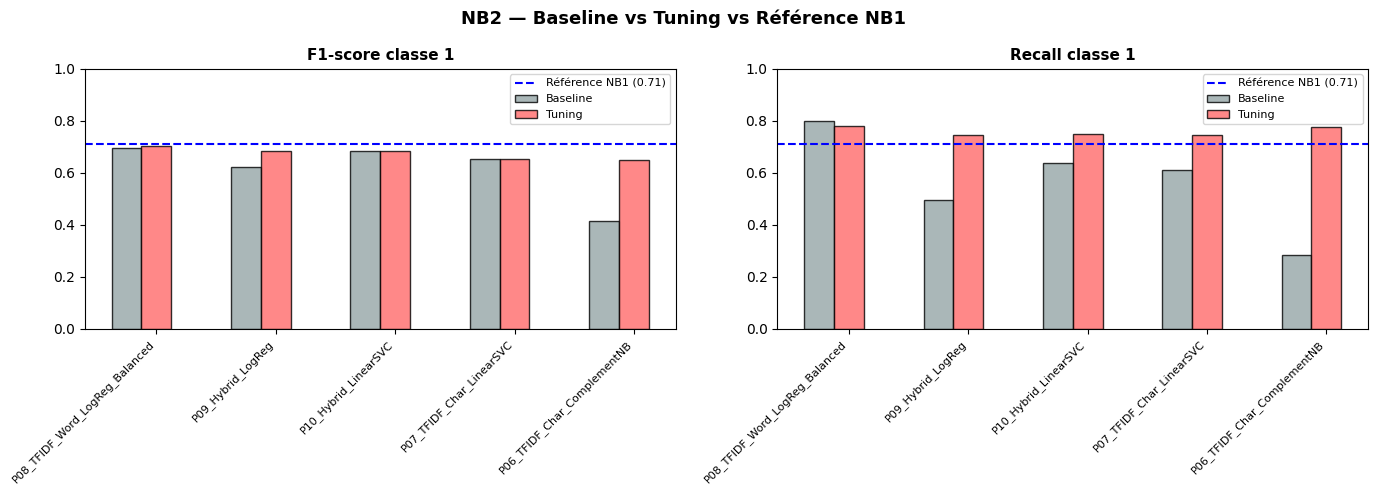

In [8]:
# ── COMPARAISON BASELINE VS TUNING ───────────────────────────────────────────
comparison = []

for _, baseline_row in baseline_df.iterrows():
    tuned_row = tuned_df[tuned_df['pipeline'] == baseline_row['pipeline']].iloc[0]
    comparison.append({
        'pipeline'             : baseline_row['pipeline'],
        'baseline_f1_class_1'  : baseline_row['test_f1_class_1'],
        'tuned_f1_class_1'     : tuned_row['test_f1_class_1'],
        'delta_f1_class_1'     : tuned_row['test_f1_class_1'] - baseline_row['test_f1_class_1'],
        'baseline_recall'      : baseline_row['test_recall_class_1'],
        'tuned_recall'         : tuned_row['test_recall_class_1'],
        'delta_recall'         : tuned_row['test_recall_class_1'] - baseline_row['test_recall_class_1'],
        'vs_NB1_reference'     : tuned_row['test_f1_class_1'] - REFERENCE_F1,
        'best_params'          : tuned_row['best_params'],
    })

comparison_df = pd.DataFrame(comparison).round(3)
comparison_df = comparison_df.sort_values('tuned_f1_class_1', ascending=False)

print("=== Comparaison Baseline vs Tuning NB2 ===")
display(comparison_df)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x     = range(len(comparison_df))
width = 0.25

for ax, metric_base, metric_tuned, title in zip(
    axes,
    ['baseline_f1_class_1', 'baseline_recall'],
    ['tuned_f1_class_1', 'tuned_recall'],
    ['F1-score classe 1', 'Recall classe 1']
):
    ax.bar([i - width for i in x], comparison_df[metric_base],
           width, label='Baseline', color='#95A5A6', edgecolor='black', alpha=0.8)
    ax.bar([i for i in x], comparison_df[metric_tuned],
           width, label='Tuning', color='#FF6B6B', edgecolor='black', alpha=0.8)
    ax.axhline(REFERENCE_F1, color='blue', linestyle='--',
               linewidth=1.5, label=f'Référence NB1 ({REFERENCE_F1})')
    ax.set_xticks(list(x))
    ax.set_xticklabels(comparison_df['pipeline'], rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('NB2 — Baseline vs Tuning vs Référence NB1',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Sauvegarde des résultats

On sauvegarde les résultats de NB2 pour le tableau comparatif global.

In [9]:
# ── SAUVEGARDE DES RÉSULTATS ──────────────────────────────────────────────────
baseline_df.to_csv('/kaggle/working/NB2_baseline_results.csv', index=False)
tuned_df.to_csv('/kaggle/working/NB2_tuned_results.csv', index=False)
comparison_df.to_csv('/kaggle/working/NB2_comparison_results.csv', index=False)

print("✅ Résultats sauvegardés :")
print("   → /kaggle/working/NB2_baseline_results.csv")
print("   → /kaggle/working/NB2_tuned_results.csv")
print("   → /kaggle/working/NB2_comparison_results.csv")

print(f"\nMeilleur pipeline NB2 (tuning) : {tuned_df.iloc[0]['pipeline']}")
print(f"F1 classe 1    : {tuned_df.iloc[0]['test_f1_class_1']:.3f}")
print(f"Recall classe 1 : {tuned_df.iloc[0]['test_recall_class_1']:.3f}")
print(f"Meilleurs paramètres : {tuned_df.iloc[0]['best_params']}")
print(f"\nComparaison avec NB1 :")
print(f"NB1 meilleur F1 : {REFERENCE_F1:.3f}")
print(f"NB2 meilleur F1 : {tuned_df.iloc[0]['test_f1_class_1']:.3f}")
delta = tuned_df.iloc[0]['test_f1_class_1'] - REFERENCE_F1
print(f"Delta           : {delta:+.3f} {'🟢' if delta > 0 else '🔴'}")

✅ Résultats sauvegardés :
   → /kaggle/working/NB2_baseline_results.csv
   → /kaggle/working/NB2_tuned_results.csv
   → /kaggle/working/NB2_comparison_results.csv

Meilleur pipeline NB2 (tuning) : P08_TFIDF_Word_LogReg_Balanced
F1 classe 1    : 0.705
Recall classe 1 : 0.781
Meilleurs paramètres : {"clf__C": 2.0}

Comparaison avec NB1 :
NB1 meilleur F1 : 0.710
NB2 meilleur F1 : 0.705
Delta           : -0.005 🔴
